# Thymus — spatial RNA + protein (CITE-seq)

- This tutorial runs LYNX on a multi-cellular, high-throughput mouse-thymus section that pairs **spatial RNA** (the *reference* modality) with **protein abundance (CITE-seq)** (the *query* modality).
- LYNX reconstructs denoised gene expression and infers the cortex → medulla axis with a principal **curve**, then discretises it into zones.

In [1]:
import os

import numpy as np
import scanpy as sc
import squidpy as sq

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})
import lynx

/home/yinuo/Desktop/azizi_lab/IMS/env/lib/python3.9/site-packages/numba/core/decorators.py:282: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


## 1. Load the paired RNA + protein modalities

In [2]:
n_subgraphs, k = 16, 8
n_hidden, n_latent = 32, 6
n_epochs, lr, patience = 500, 1e-2, 20

data_path = "../../data/thymus/"
sample_id = "Mouse_Thymus1"

adata_rna = sc.read_h5ad(os.path.join(data_path, sample_id, "adata_rna.h5"))
adata_protein = sc.read_h5ad(os.path.join(data_path, sample_id, "adata_protein.h5"))
adata_protein.var_names_make_unique()
cluster_key = "cell_type" if "cell_type" in adata_rna.obs.keys() else None

/home/yinuo/Desktop/azizi_lab/IMS/env/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 2. Build the spatial hetero-graph, configure the model

Both modalities are measured on a multicellular spatial grid, so we set
`is_ref_grid` / `is_query_grid`. Cell-interaction inference is left off here due to the lack of single-cell-resolution annotation

In [3]:
graph_data = lynx.dataset.HeteroDataset(
    adatas_ref=adata_rna,
    adatas_query=adata_protein,
    n_subgraphs=n_subgraphs,
    k=k, is_weighted=True,
    cluster_key=cluster_key,
    is_query_grid=True,
    is_ref_grid=True,
    query="protein", query_proj_key="spatial",
    ref="rna", ref_proj_key="spatial",
)

train_configs = lynx.config.set_train_configs(
    n_epochs=n_epochs, lr=lr, patience=patience,
    device=torch.device("cuda"),
)
model_configs = lynx.config.set_model_configs(
    graph_data=graph_data,
    c_hidden=n_hidden, c_latent=n_latent,
    act=nn.SiLU(),
    infer_cell_interaction=False,
)

2026-06-24 23:56:27.718992: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-24 23:56:28.538734: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## 3. Train the model

Epoch 81 train -ELBO: 292.705; val -ELBO: 309.381; val R2: 0.994; q(z) corr: 0.386; p(z) corr: 0.577:  16%|█▋        | 82/500 [01:07<05:43,  1.22it/s]
/home/yinuo/Desktop/azizi_lab/IMS/models/base_model.py:490: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/home/yinuo/Desktop/azizi_lab/IMS/models/base_model.py:470: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


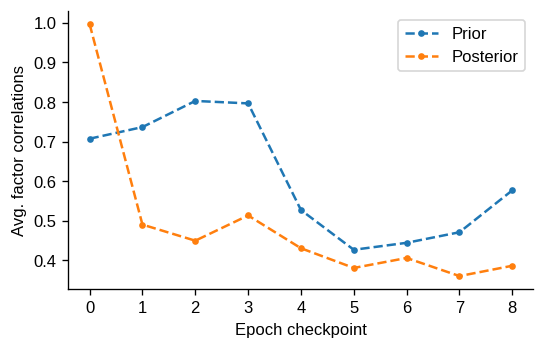

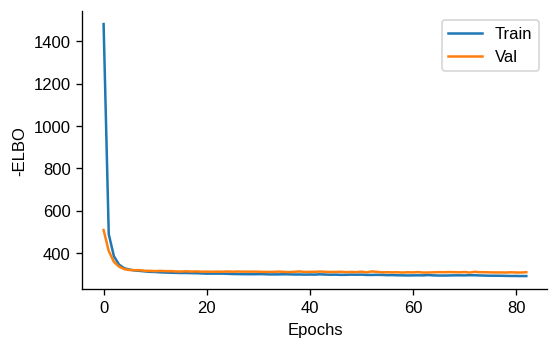

In [4]:
model = lynx.model.HeteroAttnVGAE(model_configs, device=torch.device("cuda"))
model.fit(graph_data, train_configs, DEBUG=True)
res = model.evaluate(
    adata_rna, adata_protein,
    graph_data=graph_data,
    n_subgraphs=1,
    device=torch.device("cpu"),
)
adata_rna.layers["px"] = res["px"].copy()

```Python
# Save results into a full h5ad (AnnData) carrying the latent embedding and the
# reconstructed gene expression (`layers["px"]`).
results_dir = "../../results/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)
adata_rna.write_h5ad(os.path.join(results_dir, "LYNX_thymus_rna.h5ad"))
```

### Reconstruction quality

Observed vs. reconstructed gene expression should fall along the diagonal.

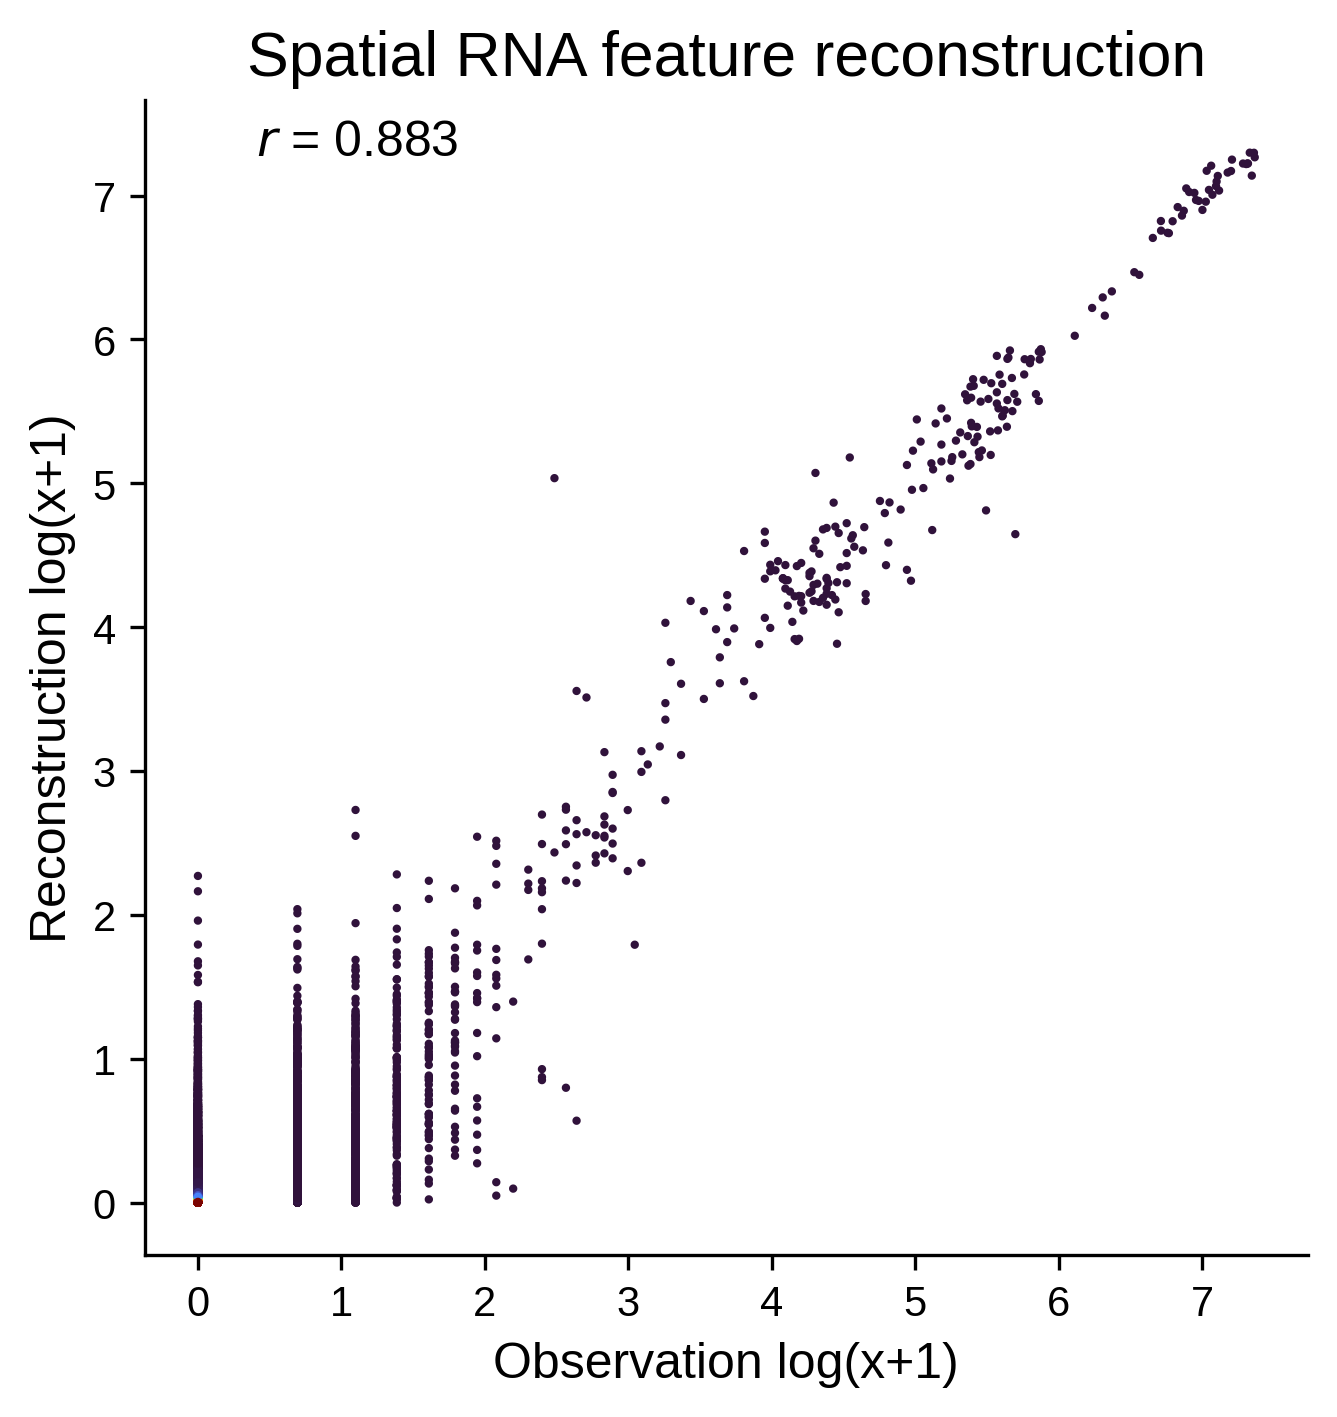

In [5]:
lynx.plot.disp_kde_scatter(
    adata_rna.X.flatten(),
    res.px.flatten(),
    xlabel=r"Observation log(x+1)",
    ylabel=r"Reconstruction log(x+1)",
    title="Spatial RNA feature reconstruction",
)

## 3. Load the pre-saved result snapshot

Training above requires the full (large) RNA / protein inputs and a GPU. For the
downstream analysis we load a LYNX result snapshot — the same object the training
step produces, carrying the latent embedding `X_z` and the spatial coordinates
needed for the trajectory and zonation below.

In [6]:
results_dir = "../../results/"
adata_rna = sc.read_h5ad(os.path.join(results_dir, "LYNX_thymus_rna.h5ad"))

## 4. Trajectory inference (principal curve)

Fit a principal curve through the latent embedding and orient the cortex →
medulla axis with a cortex marker (`Dcn`).

(2, 6)
(20, 6)
Computing pseudotime on principal curve...


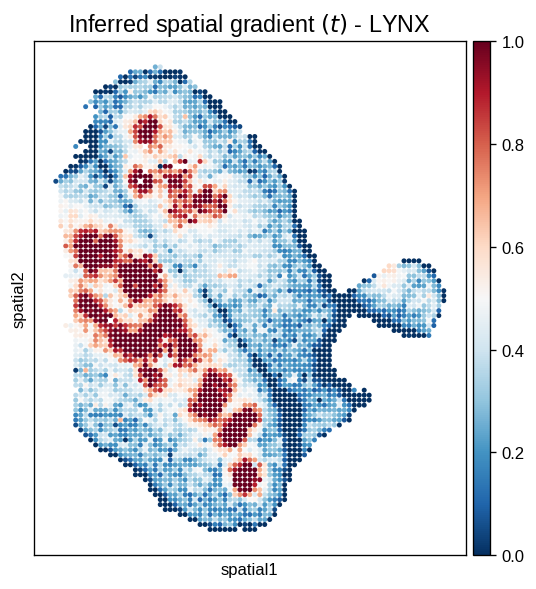

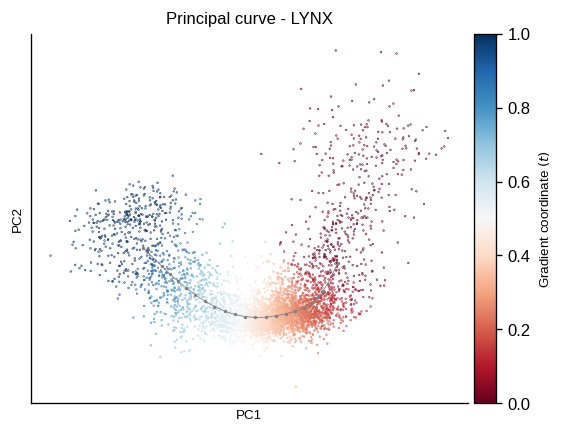

In [7]:
curve = lynx.trajectory.get_curve(adata_rna)
lynx.trajectory.compute_pseudotime(adata_rna, curve, root_marker="Dcn")

ax = sq.pl.spatial_scatter(
    adata_rna, color="t",
    cmap="RdBu_r", size=100, img=False, return_ax=True, title=None,
)
ax.set_title(r"Inferred spatial gradient $(t)$ - LYNX", fontsize=14)

lynx.plot.disp_trajectory(
    adata_rna, cmap="RdBu",
    title="Principal curve - LYNX",
)

## 5. Zonation

/home/yinuo/Desktop/azizi_lab/IMS/env/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:488: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)


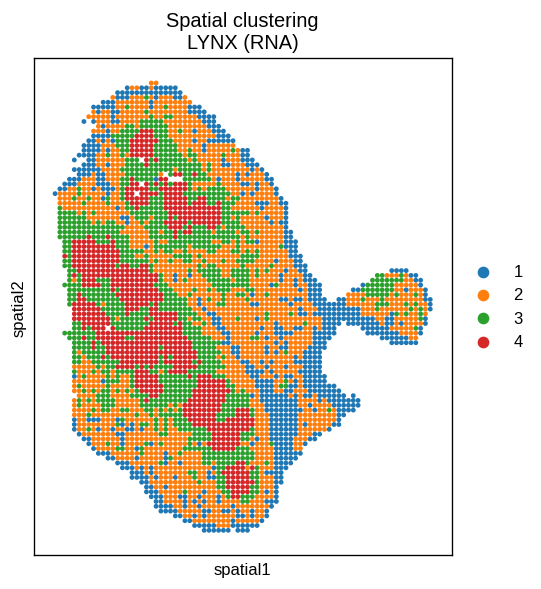

In [8]:
if "milestones_colors" in adata_rna.uns_keys():
    adata_rna.uns.pop("milestones_colors")

lynx.utils.get_zonations(adata_rna, n_zones=4)
sq.pl.spatial_scatter(
    adata_rna, color="zone",
    size=100, img=False,
    title="Spatial clustering\nLYNX (RNA)",
)